Import necessary libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
from PIL import Image
import io

Step 1: Load images from Google Drive via direct link

In [2]:
# Google Drive image direct links
url1 = "https://drive.google.com/uc?export=download&id=1l6GUpW_CuYxRPdTLt2uRnLB7V4EZaFSe"  # scene1
url2 = "https://drive.google.com/uc?export=download&id=1mf8q4SB6ipeTO65VAJfIBWwtV4LZMjDo"  # scene2

def load_image_from_url(url):
    resp = urlopen(url)
    image = np.asarray(bytearray(resp.read()), dtype="uint8")
    return cv2.imdecode(image, cv2.IMREAD_COLOR)

img1 = load_image_from_url(url1)
img2 = load_image_from_url(url2)

# Convert to grayscale (required for keypoint detection)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

Step 2: Feature Detection and Description

    ➤ SIFT (Scale-Invariant Feature Transform)
        Detects blobs in scale-space using DoG and computes 128D descriptors

    ➤ ORB (Oriented FAST and Rotated BRIEF)
        FAST for keypoints, BRIEF for binary descriptors (rotation invariant)

    ➤ AKAZE (Accelerated KAZE)
        Detects nonlinear scale space features and binary descriptors

In [3]:
sift = cv2.SIFT_create()
kp1_sift, des1_sift = sift.detectAndCompute(gray1, None)
kp2_sift, des2_sift = sift.detectAndCompute(gray2, None)


orb = cv2.ORB_create()
kp1_orb, des1_orb = orb.detectAndCompute(gray1, None)
kp2_orb, des2_orb = orb.detectAndCompute(gray2, None)


akaze = cv2.AKAZE_create()
kp1_akaze, des1_akaze = akaze.detectAndCompute(gray1, None)
kp2_akaze, des2_akaze = akaze.detectAndCompute(gray2, None)

Step 3: Feature Matching using Brute Force Matcher

In [4]:
# For SIFT and AKAZE, use L2 norm; for ORB, use Hamming distance
bf_sift = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
bf_akaze = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches_sift = bf_sift.match(des1_sift, des2_sift)
matches_orb = bf_orb.match(des1_orb, des2_orb)
matches_akaze = bf_akaze.match(des1_akaze, des2_akaze)

# Sort matches by distance (lower is better)
matches_sift = sorted(matches_sift, key=lambda x: x.distance)
matches_orb = sorted(matches_orb, key=lambda x: x.distance)
matches_akaze = sorted(matches_akaze, key=lambda x: x.distance)

Step 4: Draw top 50 matches for each

In [5]:
img_sift = cv2.drawMatches(img1, kp1_sift, img2, kp2_sift, matches_sift[:50], None, flags=2)
img_orb = cv2.drawMatches(img1, kp1_orb, img2, kp2_orb, matches_orb[:50], None, flags=2)
img_akaze = cv2.drawMatches(img1, kp1_akaze, img2, kp2_akaze, matches_akaze[:50], None, flags=2)

Step 5: Display results

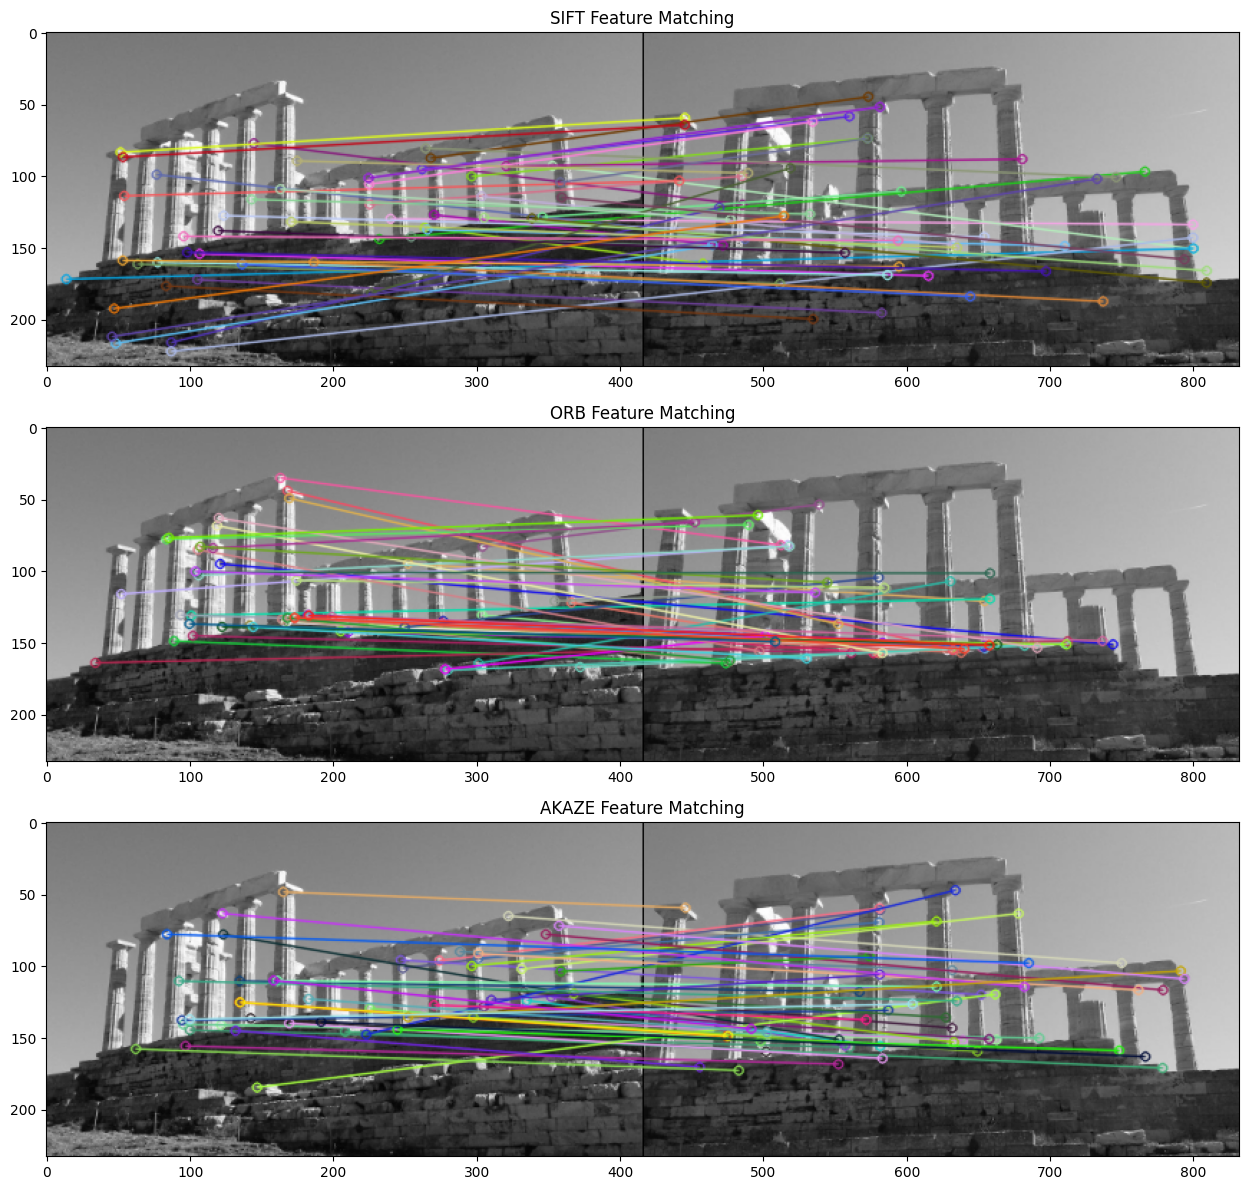

In [6]:
plt.figure(figsize=(20, 12))
plt.subplot(3, 1, 1)
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT Feature Matching")

plt.subplot(3, 1, 2)
plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matching")

plt.subplot(3, 1, 3)
plt.imshow(cv2.cvtColor(img_akaze, cv2.COLOR_BGR2RGB))
plt.title("AKAZE Feature Matching")

plt.tight_layout()
plt.show()